In [2]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [3]:
import torch
import torch.nn as nn
import torch.optim as optim
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import MinMaxScaler

In [9]:
dataset1 = pd.read_csv('/content/drive/MyDrive/deep learning/ex1 - Sheet1.csv')
dataset1.columns = dataset1.columns.str.strip().str.upper()
X = dataset1[['X']].values
Y = dataset1[['Y']].values

In [10]:
dataset1.head()

,X,Y
0,30,87
1,40,67
2,50,65
3,34,89
4,21,98


In [13]:
X_train, X_test, y_train, y_test = train_test_split(X, Y, test_size=0.33, random_state=33)

In [14]:
scaler = MinMaxScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

In [15]:
X_train_tensor = torch.tensor(X_train, dtype=torch.float32)
y_train_tensor = torch.tensor(y_train, dtype=torch.float32).view(-1, 1)
X_test_tensor = torch.tensor(X_test, dtype=torch.float32)
y_test_tensor = torch.tensor(y_test, dtype=torch.float32).view(-1, 1)

In [18]:
# Name: Mohamed Zabir Khan A
# Register Number: 212224230162
class NeuralNet(nn.Module):
  def __init__(self):
        super().__init__()
        self.fc1=nn.Linear(1,8)
        self.fc2 = nn.Linear(8,10)
        self.fc3 = nn. Linear(10,1)
        self.relu = nn.ReLU()
        self.history = {'Loss': []}
  def forward(self , x):
    x=self.relu(self.fc1(x))
    x=self.relu(self.fc2(x))
    x=self.fc3 (x)
    return x

In [19]:
ai_brain = NeuralNet()
criterion = nn.MSELoss()
optimizer = optim.RMSprop(ai_brain.parameters(), lr=0.001)

In [22]:
# Name: Mohamed Zabir Khan A
# Register Number: 212224230162
def train_model(ai_brain, X_train, y_train, criterion, optimizer, epochs=2000):
    for epoch in range(epochs):
        optimizer.zero_grad()

        outputs = ai_brain(X_train)
        loss = criterion(outputs, y_train)
        loss.backward()
        optimizer.step()
        ai_brain.history['Loss'].append(loss.item())
        if epoch % 200 == 0:
            print(f'Epoch [{epoch}/{epochs}], Loss: {loss.item():.6f}')


In [23]:
train_model(ai_brain, X_train_tensor, y_train_tensor, criterion, optimizer)


Epoch [0/2000], Loss: 4799.306152
Epoch [200/2000], Loss: 4397.166992
Epoch [400/2000], Loss: 3730.852051
Epoch [600/2000], Loss: 2835.716064
Epoch [800/2000], Loss: 1875.218506
Epoch [1000/2000], Loss: 1098.126099
Epoch [1200/2000], Loss: 726.010925
Epoch [1400/2000], Loss: 667.790405
Epoch [1600/2000], Loss: 650.125854
Epoch [1800/2000], Loss: 635.316223


In [24]:
with torch.no_grad():
    test_loss = criterion(ai_brain(X_test_tensor), y_test_tensor)
    print(f'Test Loss: {test_loss.item():.6f}')


Test Loss: 442.295074


In [25]:
loss_df = pd.DataFrame(ai_brain.history)

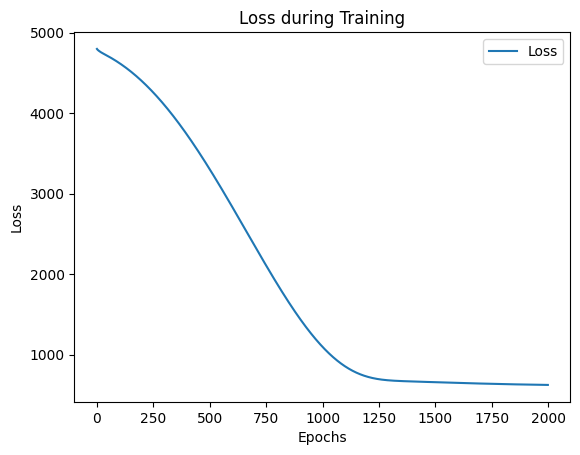

In [26]:
import matplotlib.pyplot as plt
loss_df.plot()
plt.xlabel("Epochs")
plt.ylabel("Loss")
plt.title("Loss during Training")
plt.show()

In [27]:
X_n1_1 = torch.tensor([[9]], dtype=torch.float32)
prediction = ai_brain(torch.tensor(scaler.transform(X_n1_1), dtype=torch.float32)).item()
print(f'Prediction: {prediction}')

Prediction: 54.65060043334961
